In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import pickle as pkl
import numpy as np
import random
import seaborn as sns
from scipy.stats import gaussian_kde
import os
from tqdm import tqdm

In [25]:
# Load the data
def load_data(directory, startswith=None):
    data = []

    # Load all pickle files in the directory and append their data to the list
    for filename in os.listdir(directory):
        if filename.endswith(".pkl") and (
            startswith is None or filename.startswith(startswith)
        ):
            filepath = os.path.join(directory, filename)
            with open(filepath, "rb") as f:
                data.append(pkl.load(f))

    data_no_advertisers = [
        {k: v for k, v in d[0].items() if k != "advertisers"} for d in data
    ]
    all_advertisers = [d[0]["advertisers"] for d in data]

    # Create a dataframe
    df = pd.DataFrame.from_records(data_no_advertisers, index=range(len(data)))
    return df, all_advertisers

In [26]:
df, all_advertisers = load_data("./output/results", startswith="sgd_bb_results")
print(df.head())
df_k_1 = df[df["k"] == 1]

   externality_cost_per_impression  num_advertisers  num_auctions  \
0                             0.01               20           500   
1                             0.01               20           500   
2                             0.01               20           500   

   random_seed  k  polynomial_degree                   tau  \
0         1234  1                  1            [0.0, 0.0]   
1         1234  1                  2       [0.0, 0.0, 0.0]   
2         1234  1                  3  [0.0, 0.0, 0.0, 0.0]   

                                           w_vcg_adv  \
0  [215478.94708323167, 405802.6274636072, 228500...   
1  [215478.94708323167, 405802.6274636072, 228500...   
2  [215478.94708323167, 405802.6274636072, 228500...   

                                          w_coll_adv  \
0  [215478.94708323167, 405802.6274636072, 228500...   
1  [215478.94708323167, 405802.6274636072, 228500...   
2  [215478.94708323167, 405802.6274636072, 228500...   

                        

In [27]:
def tau(externality, coeffs):
    tau_val = 0
    for i, coeff in enumerate(coeffs):
        tau_val += coeff * (externality**i)
    return tau_val


def print_tau(coeffs):
    terms = []
    for i, coeff in enumerate(coeffs):
        if i == 0:
            terms.append(f"{coeff:.4f}")
        elif i == 1:
            terms.append(f"{coeff:.4f}*x")
        else:
            terms.append(f"{coeff:.4f}*x^{i}")
    return " + ".join(terms)


def plot_advertisers(auction_output, ad_scaler=1, ext_scaler=1):
    # plot all advertisers and best line
    advertisers = auction_output["advertisers"]
    tau_coeffs = auction_output["tau"]
    v = [ad[0] * ad_scaler for advertisers_set in advertisers for ad in advertisers_set]
    e = [
        ad[1] * ext_scaler for advertisers_set in advertisers for ad in advertisers_set
    ]
    min_e, max_e = min(e), max(e) * 1.1
    division_size = int(((2 * max_e) - min_e) / 100)
    tau_x = [min_e + i * division_size for i in range(100)]
    tau_y = [tau(t, tau_coeffs) for t in tau_x]

    fig, axs = plt.subplots(1, 1, figsize=(10, 5))

    axs.scatter(e, v, alpha=0.5)
    axs.plot(tau_x, tau_y, color="red")
    axs.set_ylabel("Advertiser Value")
    axs.set_xlabel("Externality Value")
    axs.set_title("Social Welfare Values vs Advertiser Values with Best Tau Line")

    # set x and y limits
    axs.set_xlim(min_e, max_e)
    axs.set_ylim(0, max(v) * 1.1)
    fig.show()


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """Create a new colormap from a subset (minval->maxval) of an existing cmap."""
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n)),
    )
    return new_cmap

# Plotting the Data

Desired plots are:
- ~~Ad. welfare from Ext. welfare for each polynomial degree~~
- ~~triplot of change in welfare vs externality cost~~
- ~~example of tau with advertisers~~
- ~~tau from different k and poly but same lambda~~
- ~~histogram distributions of welfare values~~

ValueError: setting an array element with a sequence.

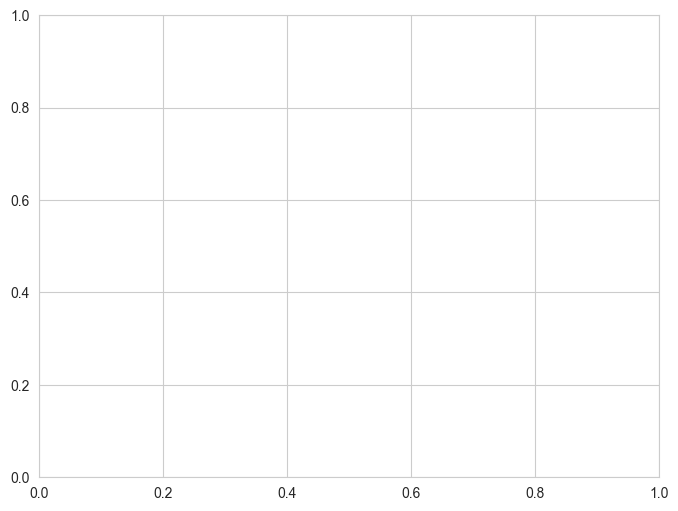

In [28]:
# Plot ad welfare vs ext welfare


sns.set_style("whitegrid")
# Define a mapping from polynomial_degree to a named colormap
cmap_dict = {1: "Blues", 2: "Reds", 3: "Greens"}

original_blues = plt.cm.Blues
short_blues = truncate_colormap(original_blues, minval=0.5, maxval=1.0)


plt.figure(figsize=(8, 6))
# We will keep track of the min and max of externality_cost_per_impression
# so that each scatter uses the same color scale
vmin = df["externality_cost_per_impression"].min()
vmax = df["externality_cost_per_impression"].max()

for poly in [1, 2, 3]:
    subset = df_k_1[df_k_1["polynomial_degree"] == poly]

    # Plot each subset with its own colormap
    scatter = plt.scatter(
        x=subset["w_coll_ext"],
        y=subset["w_coll_adv"],
        c=subset["externality_cost_per_impression"],
        cmap=short_blues,
        alpha=0.7,  # slightly transparent
        vmin=vmin,  # ensures consistent color scale across subsets
        vmax=vmax,
        label=f"polynomial degree={poly}",
    )
# A single colorbar for all points
cbar = plt.colorbar(scatter, label="Externality Cost Per Impression")

plt.xlabel("Externality Welfare")
plt.ylabel("Advertiser Welfare")
plt.title("Advertiser vs. Externality Welfare")
# plt.legend(title='Tau Polynomial Degree')
# plt.tight_layout()
plt.show()

In [ ]:
df_k_1["w_adv_change"] = (df_k_1["w_coll_adv"] - df_k_1["w_vcg_adv"]) / 1000
df_k_1["w_ext_change"] = (df_k_1["w_coll_ext"] - df_k_1["w_vcg_ext"]) / 1000
df_k_1["w_tot_change"] = (df_k_1["w_coll_tot"] - df_k_1["w_vcg_tot"]) / 1000

y_labels = [
    "Change in Advertiser Welfare (thousands)",
    "Change in Externality Welfare (thousands)",
    "Change in Total Welfare (thousands)",
]

# three subplots for each change in welfare
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(["w_adv_change", "w_ext_change", "w_tot_change"]):
    for poly in [1]:  # , 2, 3]:
        subset = df_k_1[df_k_1["polynomial_degree"] == poly]
        subset.sort_values(by="externality_cost_per_impression", inplace=True)

        # Plot each subset with its own colormap
        scatter = axs[i].plot(
            subset["externality_cost_per_impression"],
            subset[col],
            marker="o",
            alpha=0.7,  # slightly transparent
            label=f"polynomial degree={poly}",
        )
    axs[i].set_ylabel(y_labels[i])
    axs[i].set_xlabel("Externality Cost Per Impression")

# set figure title
fig.suptitle("Change in Welfare vs. Externality Cost")

# --- Deduplicate handles & labels across subplots ---
# 1. Collect from each axis
handles, labels = [], []
for ax in axs:
    handle, label = ax.get_legend_handles_labels()
    handles.extend(handle)
    labels.extend(label)

# 2. Remove duplicates by zipping into a dict
by_label = dict(zip(labels, handles))

# 3. Create one legend for the figure, using unique labels
# fig.legend(by_label.values(), by_label.keys(),
#            title='Tau Polynomial Degree',
#            loc='lower right')
# fig.tight_layout()
fig.show()

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [30]:
df_for_example_tau = df_k_1[df_k_1["externality_cost_per_impression"] == 0.01]
df_indices = df_for_example_tau.index

# plot advertisers and tau line for each row


def plot_advertisers_and_tau(df, save=False, file_tag=""):
    df_for_example_tau = df[df["externality_cost_per_impression"] == 0.01]
    df_indices = df_for_example_tau.index

    titles = ["Affine Tau", "Quadratic Tau", "Cubic Tau"]
    titles = [
        f"{title} (W={round(np.mean(df_for_example_tau['w_coll_tot'].iloc[i]), 3)})"
        for i, title in enumerate(titles)
    ]

    # three subplots for each change in welfare
    fig, axs = plt.subplots(1, 3, figsize=(14, 5))

    for i in range(3):
        subset = df_for_example_tau[df_for_example_tau["polynomial_degree"] == i + 1]
        advertisers = all_advertisers[df_indices[i]]

        tau_coeffs = subset["tau"].iloc[0]
        print(f"Tau Coefficients (degree {i + 1}): {print_tau(tau_coeffs)}")

        v = [ad[0] for advertisers_set in advertisers for ad in advertisers_set]
        e = [ad[1] for advertisers_set in advertisers for ad in advertisers_set]
        min_e, max_e = min(e), max(e) * 1.1
        division_size = ((2 * max_e) - min_e) / 100
        tau_x = [min_e + i * division_size for i in range(100)]
        tau_y = [tau(t, tau_coeffs) for t in tau_x]

        axs[i].scatter(e, v, alpha=0.5)
        axs[i].plot(tau_x, tau_y, color="red")
        # axs[i].set_ylabel('Advertiser Value')
        # axs[i].set_xlabel('Externality Value')
        axs[i].set_title(titles[i])

        # set x and y limits
        axs[i].set_xlim(min_e, max_e)
        axs[i].set_ylim(-1, max(v) * 1.1)

    # set figure title
    fig.suptitle("Optimal Affine, Quadratic and Cubic Tau Functions (ζ=0.01)")
    fig.supxlabel("Externality Value")
    fig.supylabel("Advertiser Value")
    if save:
        filename = f"tau_functions_{file_tag}.png" if file_tag else "tau_functions.png"
        os.makedirs("./data/figures/", exist_ok=True)
        plt.savefig(f"./data/figures/{filename}", dpi=600)
        print(f"Saved figure to ./data/figures/{filename}")
    else:
        fig.tight_layout()
        fig.show()

Tau Coefficients (degree 1): 0.0000 + 0.0000*x
Tau Coefficients (degree 2): 0.0000 + 0.0000*x + 0.0000*x^2
Tau Coefficients (degree 3): 0.0000 + 0.0000*x + 0.0000*x^2 + 0.0000*x^3


C:\Users\gabem\AppData\Local\Temp\ipykernel_28652\3313912893.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


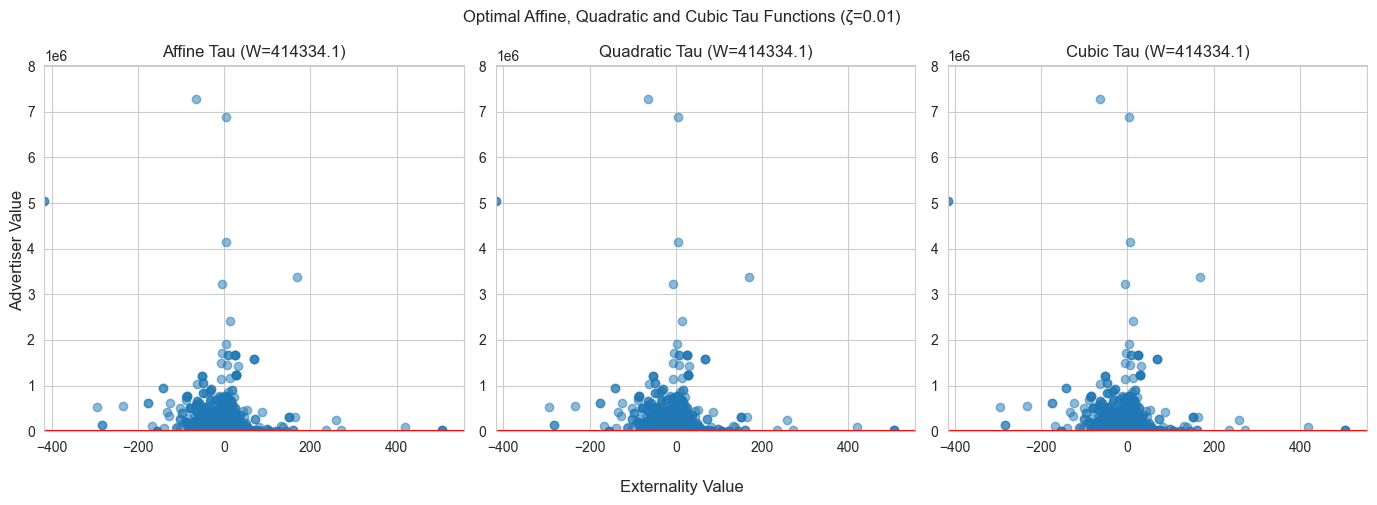

In [31]:
plot_advertisers_and_tau(df_k_1, save=False)

Tau Coefficients (degree 1): 1592526.9419 + -1.0993*x
Tau Coefficients (degree 2): 1470289.9597 + -8.7758*x + 0.0000*x^2
Tau Coefficients (degree 3): 5338685.7952 + 2.6170*x + -0.0000*x^2 + 0.0000*x^3


C:\Users\gabem\AppData\Local\Temp\ipykernel_32416\3130182949.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Tau Coefficients (degree 1): -1.2137 + 5.2460*x
Tau Coefficients (degree 2): -0.7433 + -4.2724*x + -0.3368*x^2
Tau Coefficients (degree 3): -1.7961 + 9.1099*x + -0.3913*x^2 + 6.6571*x^3
Tau Coefficients (degree 1): -0.6313 + 5.2460*x
Tau Coefficients (degree 2): 0.0613 + -2.3476*x + 0.3725*x^2
Tau Coefficients (degree 3): -0.8056 + 9.2046*x + 1.8723*x^2 + 11.4116*x^3
Tau Coefficients (degree 1): -3.3588 + 5.2460*x
Tau Coefficients (degree 2): -2.8351 + 13.0301*x + -7.6567*x^2
Tau Coefficients (degree 3): -7.3692 + 17.4587*x + -11.3174*x^2 + 4.0414*x^3
Tau Coefficients (degree 1): 0.9585 + -0.5827*x
Tau Coefficients (degree 2): 0.9880 + 4.3726*x + -0.8376*x^2
Tau Coefficients (degree 3): 1.0239 + 3.6552*x + -7.0795*x^2 + 5.9241*x^3
Tau Coefficients (degree 1): -3.3958 + 5.2460*x
Tau Coefficients (degree 2): -2.4971 + 12.3784*x + -7.1658*x^2
Tau Coefficients (degree 3): 0.8642 + -7.4787*x + -2.0648*x^2 + 1.0904*x^3
Tau Coefficients (degree 1): -3.0561 + 5.2460*x
Tau Coefficients (degree 

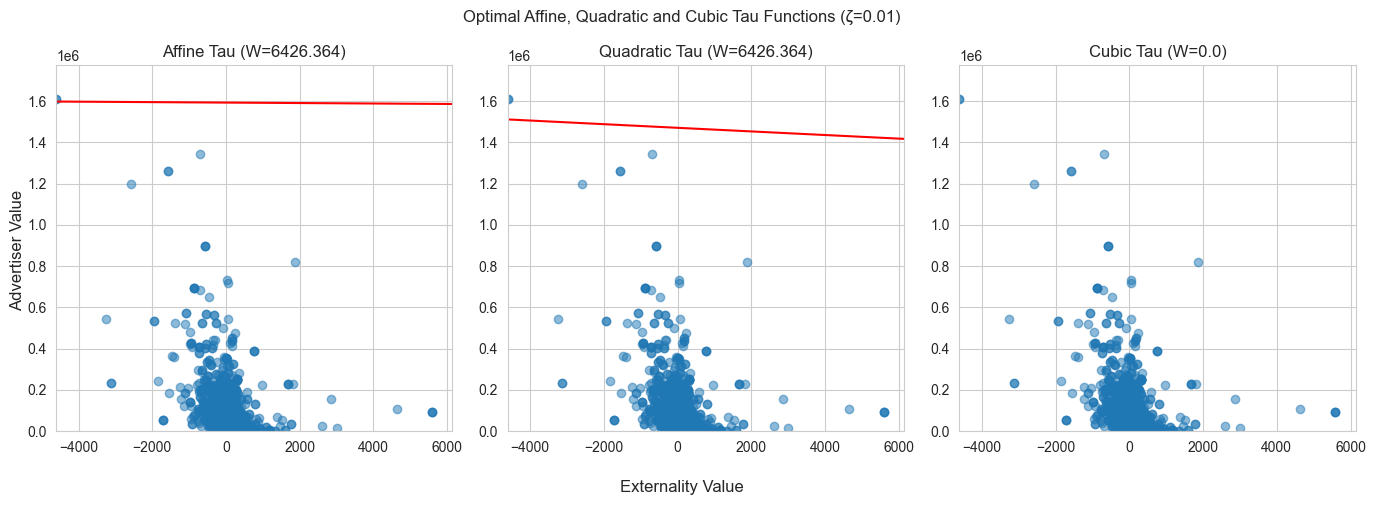

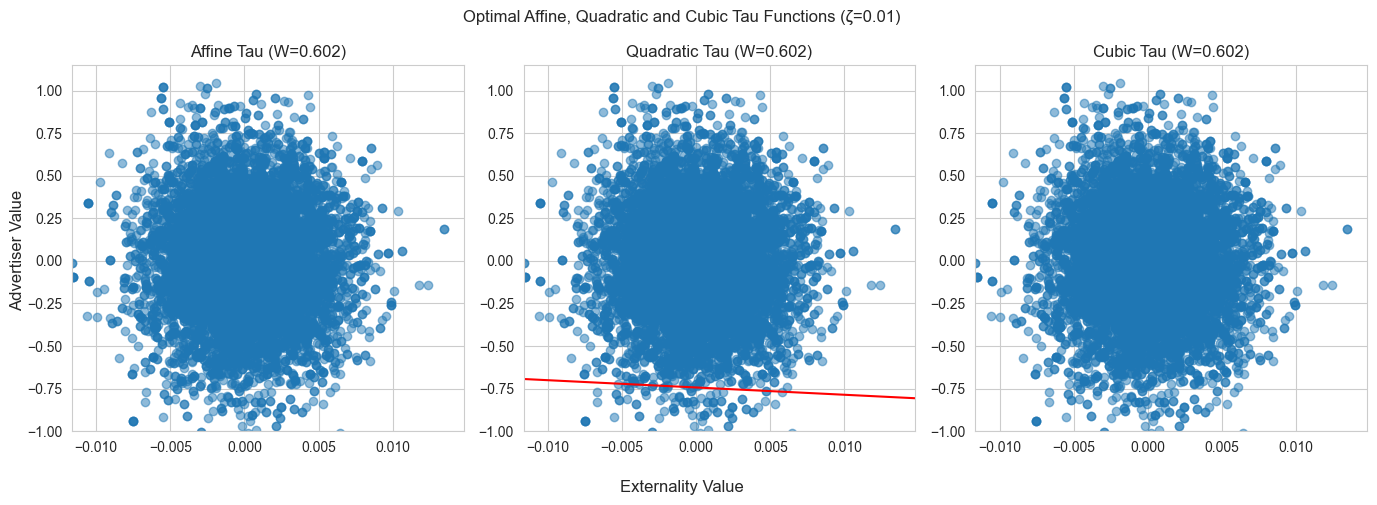

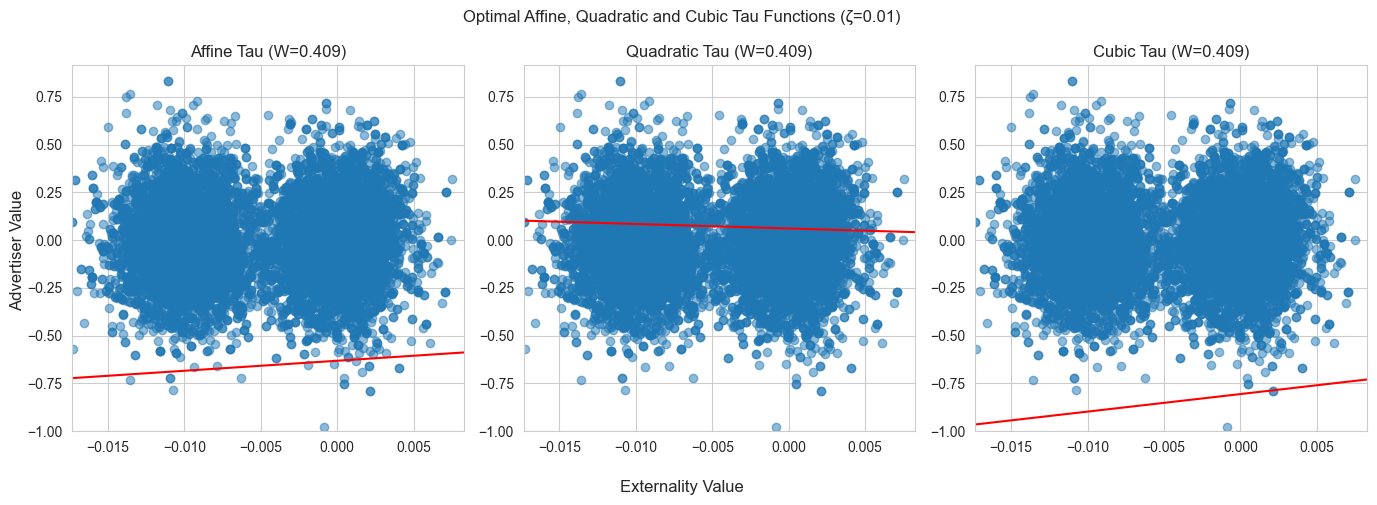

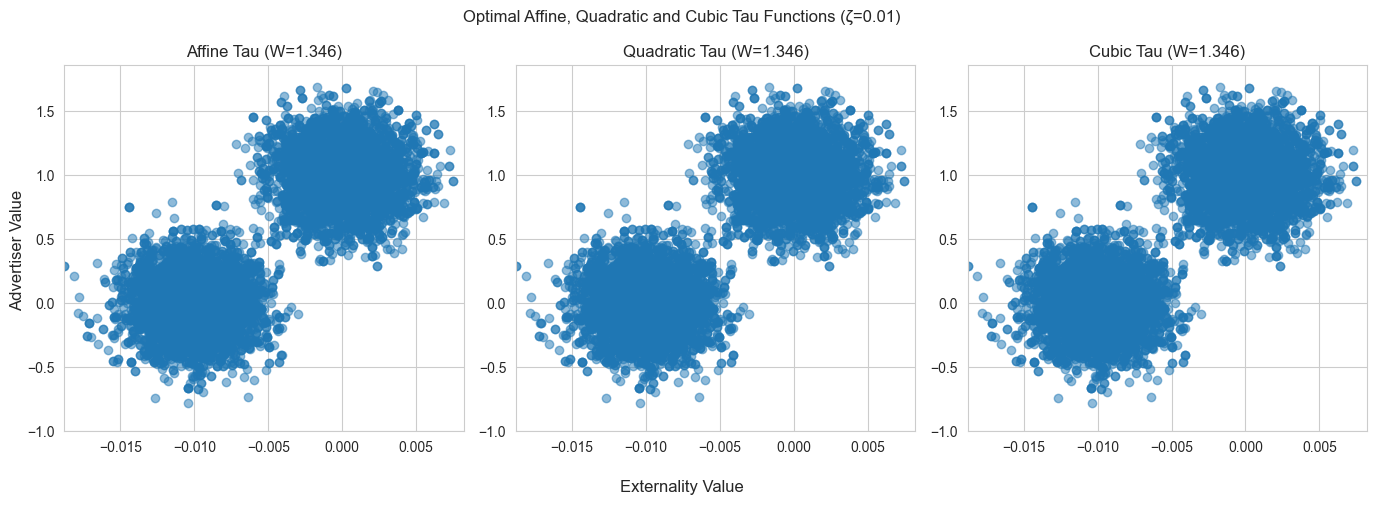

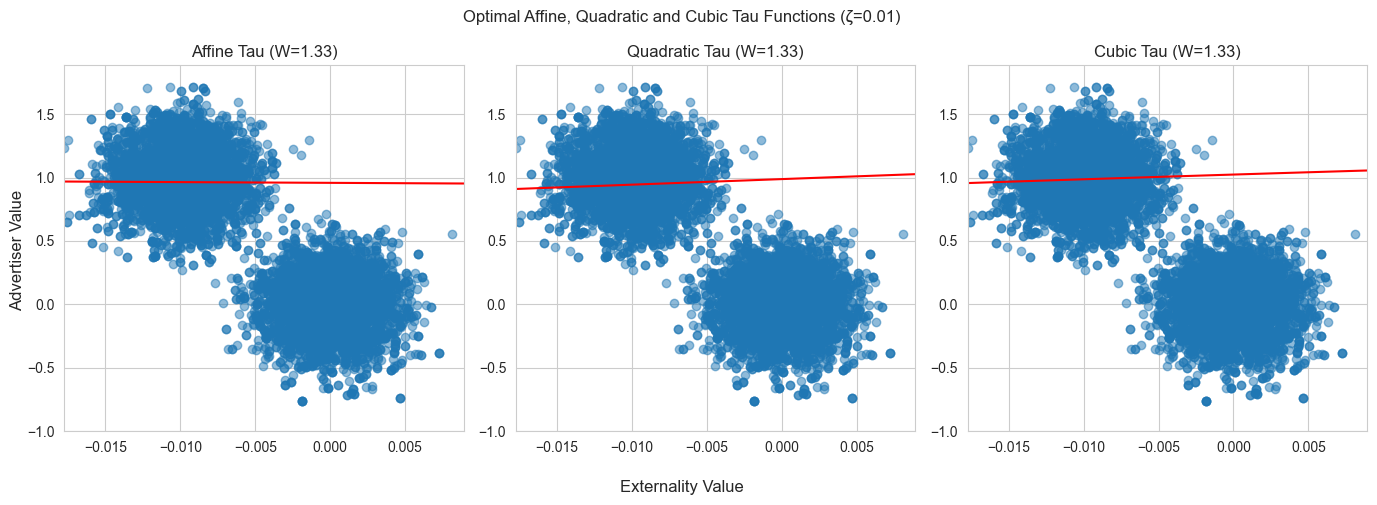

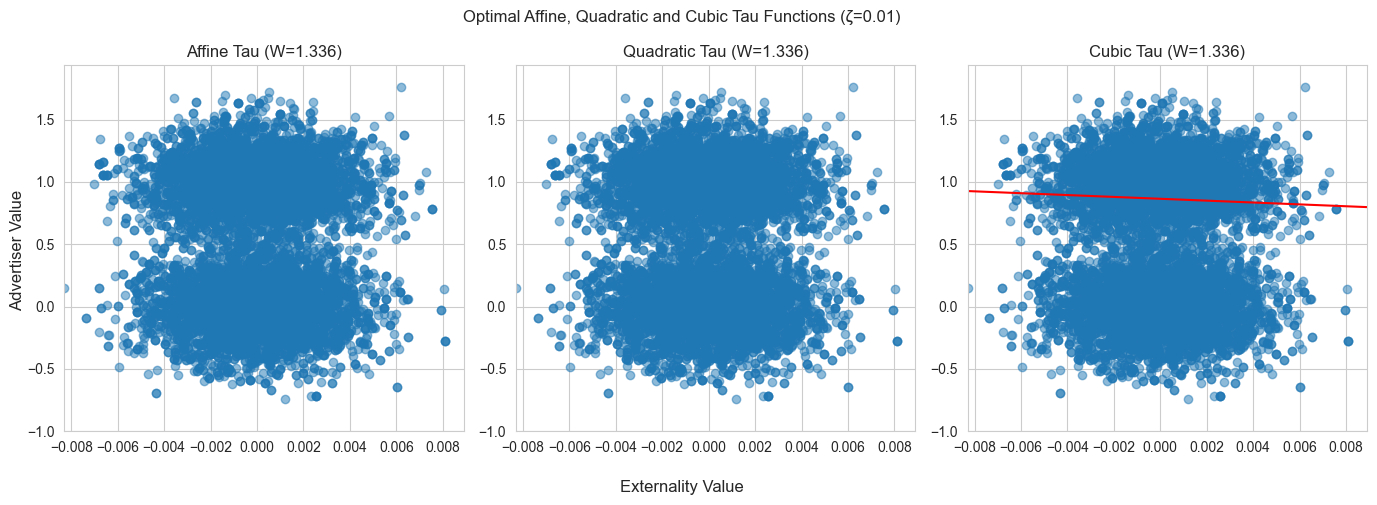

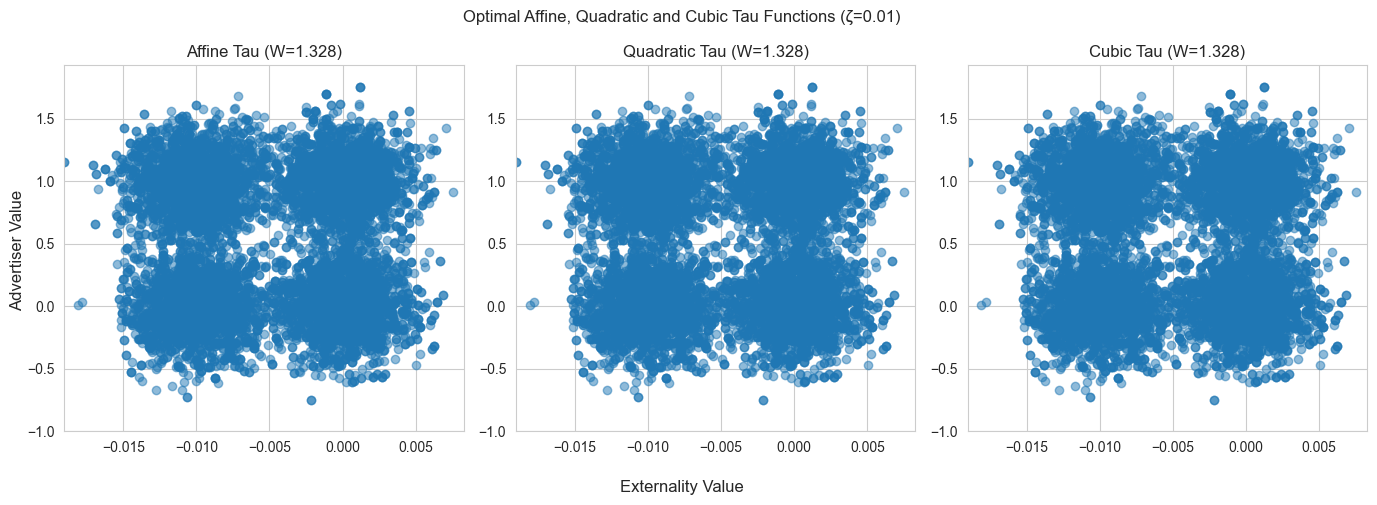

In [ ]:
tags = ["0", "a", "b", "c", "d", "e", "f"]

for tag in tags:
    df, all_advertisers = load_data("./output/results", startswith=f"ga_results_{tag}")
    df_k_1 = df[df["k"] == 1]
    plot_advertisers_and_tau(df_k_1, save=False, file_tag=tag)

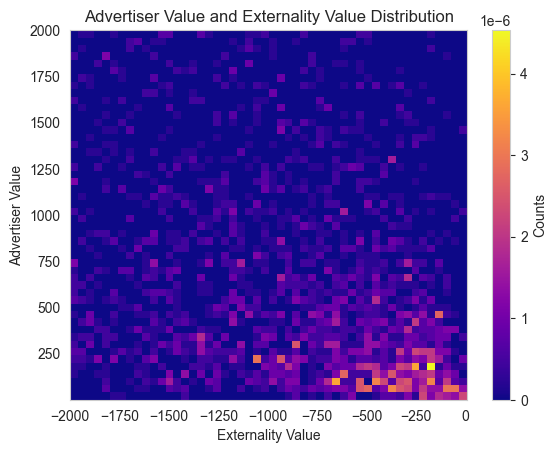

In [27]:
# plot a 2d histogram of the distribution of welfare values
df_for_example_tau = df_k_1[df_k_1["externality_cost_per_impression"] == 0.01]
df_indices = df_for_example_tau.index

advertisers = all_advertisers[df_indices[0]]

v = [ad[0] for advertisers_set in advertisers for ad in advertisers_set]
e = [ad[1] for advertisers_set in advertisers for ad in advertisers_set]

# plt.figure(figsize=(8, 8))
plt.hist2d(
    e,
    v,
    bins=(50, 50),
    range=((-2000, 10), (0, 2000)),
    density=True,
    cmap=plt.cm.plasma,
)
plt.colorbar(label="Counts")
plt.title("Advertiser Value and Externality Value Distribution")
plt.xlabel("Externality Value")
plt.ylabel("Advertiser Value")
plt.xlim(-2000, 10)
plt.ylim(min(v), 2000)
plt.grid(False)

plt.show()

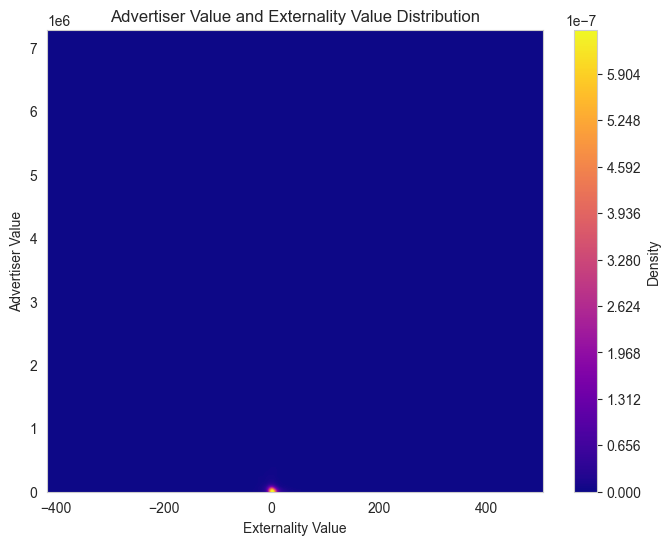

In [ ]:
df_for_example_tau = df_k_1[df_k_1["externality_cost_per_impression"] == 0.01]
df_indices = df_for_example_tau.index

advertisers = all_advertisers[df_indices[0]]

v = [ad[0] for advertisers_set in advertisers for ad in advertisers_set]
e = [ad[1] for advertisers_set in advertisers for ad in advertisers_set]

x = np.array(e)
y = np.array(v)

# Perform kernel density estimation
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# Create a grid over the data range
xgrid = np.linspace(x.min(), x.max(), 1000)
ygrid = np.linspace(y.min(), y.max(), 1000)
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
Z = kde(np.vstack([Xgrid.ravel(), Ygrid.ravel()])).reshape(Xgrid.shape)

# Plot contour
plt.figure(figsize=(8, 6))
contour = plt.contourf(Xgrid, Ygrid, Z, levels=1000, cmap="plasma")
plt.colorbar(contour, label="Density")
plt.xlabel("Externality Value")
plt.ylabel("Advertiser Value")
plt.title("Advertiser Value and Externality Value Distribution")
plt.xlim(-100, 10)
plt.ylim(0, 30000)
plt.savefig("ev_density_plot.png", dpi=600)
plt.show()

In [ ]:
# load k-sweep data
df, all_advertisers = load_data("ga_results_k_2.pkl")
print(df.shape)

In [ ]:
cmap = {1: "blue", 2: "red", 5: "orange"}
full_advertisers_set = [
    ad for advertisers_set in all_advertisers for ad in advertisers_set
]

v = [ad[0] for advertisers_set in advertisers for ad in advertisers_set]
e = [ad[1] for advertisers_set in advertisers for ad in advertisers_set]
min_e, max_e = min(e), max(e) * 1.1
division_size = int(((2 * max_e) - min_e) / 100)
tau_x = [min_e + i * division_size for i in range(100)]

plt.scatter(e, v, alpha=0.5)

for i in range(9):
    tau_coeffs = df["tau"].iloc[i]

    tau_y = [tau(t, tau_coeffs) for t in tau_x]

    plt.plot(tau_x, tau_y, color=cmap[df["k"].iloc[i]])

# set x and y limits
plt.xlim(min_e, max_e)
plt.ylim(0, max(v) * 1.1)

# Create one custom legend entry per color (k-value)
blue_line = mlines.Line2D([], [], color="blue", label="k=1")
red_line = mlines.Line2D([], [], color="red", label="k=2")
green_line = mlines.Line2D([], [], color="orange", label="k=5")

plt.legend(handles=[blue_line, red_line, green_line], loc="best", title="Value of k")


# set figure title
plt.title("Optimal Tau Functions for Varied K (ζ=0.01)")
plt.xlabel("Externality Value")
plt.ylabel("Advertiser Value")
plt.tight_layout()
plt.show()

## Plotting the Space of Functions Tested

In [22]:
# Reload sgd_bb results explicitly (df_k_1 may have been overwritten above)
df_sgd_bb, all_advertisers_sgd_bb = load_data(
    "./output/results", startswith="sgd_bb_results"
)
df_sgd_bb_k1 = df_sgd_bb[df_sgd_bb["k"] == 1]

df_for_tested = df_sgd_bb_k1[df_sgd_bb_k1["externality_cost_per_impression"] == 0.01]
fns = []
for i in range(3):
    subset = df_for_tested[df_for_tested["polynomial_degree"] == i + 1]
    tested_functions = subset["tested_functions"].iloc[0]
    fns.append(tested_functions)

# Compute axis ranges from the advertiser data
all_v = [a[0] for ads_list in all_advertisers_sgd_bb for ads in ads_list for a in ads]
all_e = [a[1] for ads_list in all_advertisers_sgd_bb for ads in ads_list for a in ads]
e_range = (min(all_e), max(all_e))
v_range = (0, max(all_v))

In [23]:
def plot_tested_functions(
    fns, save=False, max_functions=None, x_range=None, y_range=None
):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    x_lo, x_hi = x_range if x_range is not None else (-1.5, 1.5)
    y_lo, y_hi = y_range if y_range is not None else (-1.5, 1.5)
    x = np.linspace(x_lo, x_hi, 200)

    for i, order in enumerate(fns):
        sampled = (
            order
            if max_functions is None or len(order) <= max_functions
            else random.sample(order, max_functions)
        )
        for fn in tqdm(sampled):
            y = np.polyval(list(reversed(fn)), x)
            axs[i].plot(x, y, color="black", alpha=0.3, linewidth=0.5)

        axs[i].set_title(f"Order {i + 1} Functions")
        axs[i].set_xlabel("Externality Value")
        axs[i].set_ylabel("Advertiser Value")
        axs[i].set_xlim(x_lo, x_hi)
        axs[i].set_ylim(y_lo, y_hi)
        axs[i].grid(True)
    fig.suptitle("Tested Tau Functions by Polynomial Order")
    if save:
        os.makedirs("./data/figures/", exist_ok=True)
        plt.savefig("./data/figures/tested_tau_functions.png", dpi=600)
        print("Saved figure to ./data/figures/tested_tau_functions.png")
    else:
        fig.tight_layout()
        fig.show()

  0%|          | 0/2500 [00:00<?, ?it/s]

100%|██████████| 2500/2500 [00:00<00:00, 2744.68it/s]


Saved figure to ./data/figures/tested_tau_functions.png


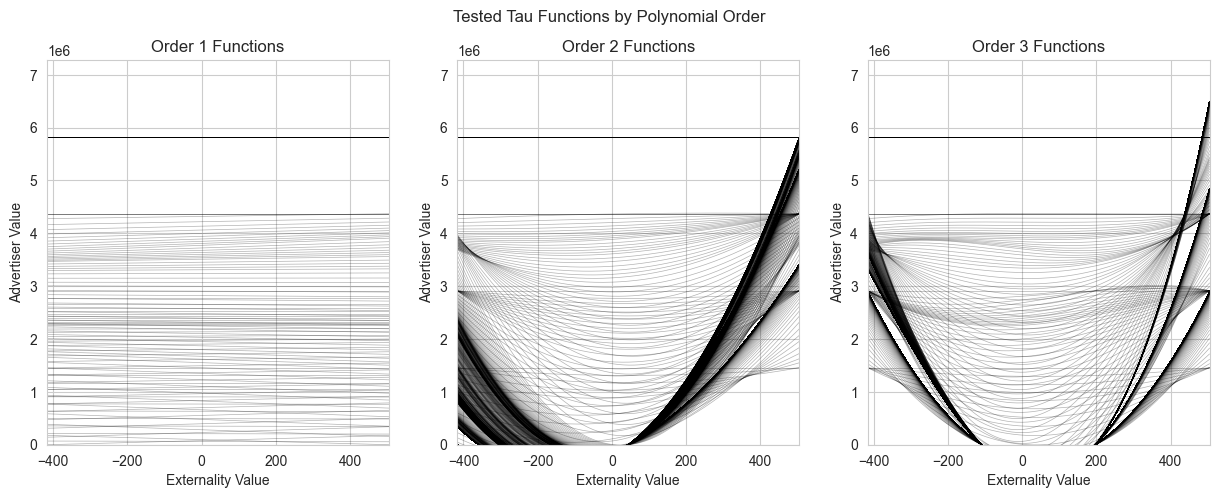

In [24]:
plot_tested_functions(
    fns, save=True, max_functions=5000, x_range=e_range, y_range=v_range
)

## Plotting the Distribution of Welfare Values

In [52]:
def column_of_lists_to_dataframe(column, name):
    # Convert a column of lists into a DataFrame with a single column
    data = []

    for lst in column:
        data.extend(lst)

    return pd.Series(data, name=name)


def plot_auctions(data, save=False):
    counterfactual_welfare = column_of_lists_to_dataframe(
        data["w_vcg_tot"], "w_vcg_tot"
    )
    collateralized_welfare = column_of_lists_to_dataframe(
        data["w_coll_tot"], "w_coll_tot"
    )

    w_vcg_ad = column_of_lists_to_dataframe(data["w_vcg_adv"], "w_vcg_adv")
    w_coll_ad = column_of_lists_to_dataframe(data["w_coll_adv"], "w_coll_adv")
    w_vcg_ex = column_of_lists_to_dataframe(data["w_vcg_ext"], "w_vcg_ext")
    w_coll_ex = column_of_lists_to_dataframe(data["w_coll_ext"], "w_coll_ext")

    # plot welfare histograms
    plt.hist(
        [counterfactual_welfare, collateralized_welfare],
        bins=30,
        alpha=0.5,
        color=["red", "blue"],
        label=["Counterfactual", "Collateralized"],
    )
    plt.legend(loc="upper right")
    plt.xlabel("Welfare")
    plt.ylabel("Frequency")
    plt.title("Welfare Distribution")

    if save:
        os.makedirs("./data/figures/", exist_ok=True)
        plt.savefig("./data/figures/total_welfare_distribution.png", dpi=600)
        print("Saved figure to ./data/figures/welfare_distribution.png")
    else:
        plt.show()

    # plot individual advertiser and externality welfares
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].hist(
        [w_vcg_ad, w_coll_ad],
        bins=30,
        alpha=0.5,
        color=["red", "blue"],
        label=["Counterfactual", "Collateralized"],
    )
    axs[0].legend(loc="upper right")
    axs[0].set_xlabel("Advertiser Welfare")
    axs[0].set_ylabel("Frequency")
    axs[0].set_title("Advertiser Welfare Distribution")

    axs[1].hist(
        [w_vcg_ex, w_coll_ex],
        bins=30,
        alpha=0.5,
        color=["red", "blue"],
        label=["Counterfactual", "Collateralized"],
    )
    axs[1].legend(loc="upper right")
    axs[1].set_xlabel("Externality Welfare")
    axs[1].set_ylabel("Frequency")
    axs[1].set_title("Externality Welfare Distribution")

    if save:
        os.makedirs("./data/figures/", exist_ok=True)
        plt.savefig("./data/figures/individual_welfare_distribution.png", dpi=600)
        print("Saved figure to ./data/figures/individual_welfare_distribution.png")
    else:
        fig.show()

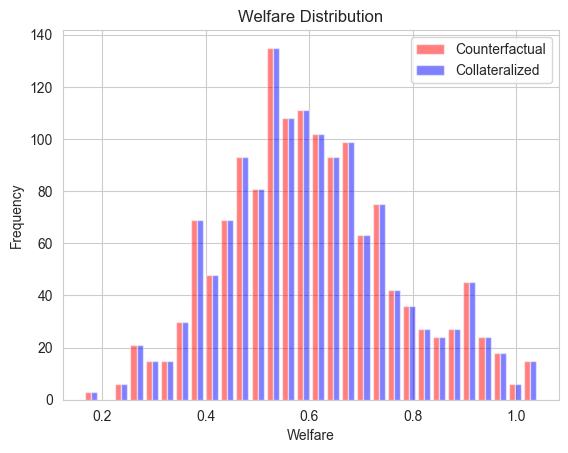

C:\Users\gabem\AppData\Local\Temp\ipykernel_32416\155502915.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


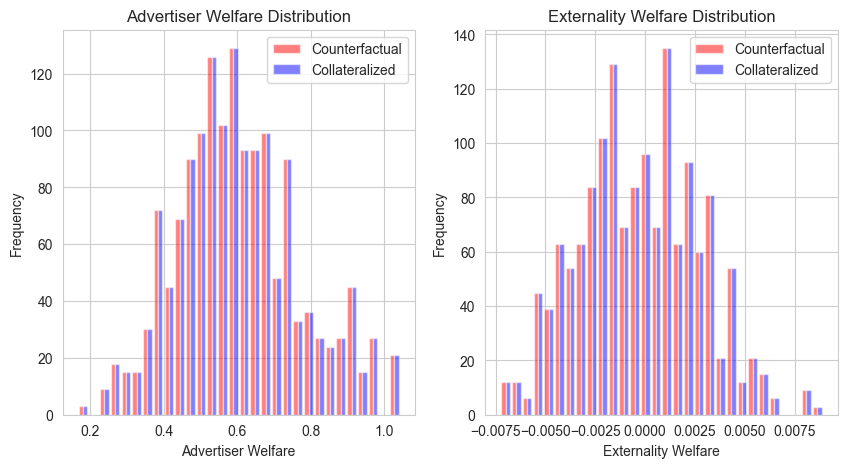

In [57]:
plot_auctions(df_k_1[df_k_1["externality_cost_per_impression"] == 0.01], save=False)

In [58]:
data = df_k_1[df_k_1["externality_cost_per_impression"] == 0.01]
data = data[data["polynomial_degree"] == 1]


counterfactual_welfare = column_of_lists_to_dataframe(data["w_vcg_tot"], "w_vcg_tot")
collateralized_welfare = column_of_lists_to_dataframe(data["w_coll_tot"], "w_coll_tot")

w_vcg_ad = column_of_lists_to_dataframe(data["w_vcg_adv"], "w_vcg_adv")
w_coll_ad = column_of_lists_to_dataframe(data["w_coll_adv"], "w_coll_adv")
w_vcg_ex = column_of_lists_to_dataframe(data["w_vcg_ext"], "w_vcg_ext")
w_coll_ex = column_of_lists_to_dataframe(data["w_coll_ext"], "w_coll_ext")

welfare_df = pd.DataFrame(
    {
        "counterfactual_welfare": counterfactual_welfare,
        "collateralized_welfare": collateralized_welfare,
        "w_vcg_advertiser": w_vcg_ad,
        "w_coll_advertiser": w_coll_ad,
        "w_vcg_externality": w_vcg_ex,
        "w_coll_externality": w_coll_ex,
    }
)
print(welfare_df.describe())

       counterfactual_welfare  collateralized_welfare  w_vcg_advertiser  \
count              500.000000              500.000000        500.000000   
mean                 0.602223                0.602223          0.602521   
std                  0.165996                0.165996          0.166229   
min                  0.163693                0.163693          0.164585   
25%                  0.487209                0.487209          0.488473   
50%                  0.587125                0.587125          0.585374   
75%                  0.703863                0.703863          0.701778   
max                  1.040977                1.040977          1.042874   

       w_coll_advertiser  w_vcg_externality  w_coll_externality  
count         500.000000         500.000000          500.000000  
mean            0.602521          -0.000298           -0.000298  
std             0.166229           0.002997            0.002997  
min             0.164585          -0.007268           -0.007

In [15]:
data = df_k_1
counterfactual_welfare = data["w_vcg_tot"]
print(counterfactual_welfare.describe())

count        21.000000
mean     188275.599611
std         563.843368
min      187085.312885
25%      187916.021467
50%      188580.588333
75%      188663.659191
max      188730.115878
Name: w_vcg_tot, dtype: float64
